In [1]:
import matplotlib.pyplot as plt
import os
import xarray as xr
import pandas as pd
import numpy as np
import copy
from datetime import datetime, timedelta
from scipy.interpolate import interp1d
import sys
%load_ext autoreload
%autoreload 1
%aimport get_manobs_soundings_pr_df
%aimport soundings_functions



/fs/site8/eccc/crd/cccma/users/rml000/UQAM/projet_margaux/Pour_Mathieu_fig4/create_figure_papier/wintre-mix_fzra_and_pl/soundings_functions.py:185: SyntaxWarning: invalid escape sequence '\s'
  sep='\s+',
/fs/site8/eccc/crd/cccma/users/rml000/UQAM/projet_margaux/Pour_Mathieu_fig4/create_figure_papier/wintre-mix_fzra_and_pl/kin1d_functions.py:508: SyntaxWarning: invalid escape sequence '\s'
  temp_prof = pd.read_csv(path_wintremi_soundings+'IOP'+str(IOP_number).zfill(2)+'/master/'+list_s[sounding_number],skiprows=[1,2],header=0, encoding='ISO-8859-1',sep='\s+')


# Load df_all_events

In [ ]:

df_manobs = pd.read_csv('df_all_events_tw_29juillet2026.csv')
df_manobs_temp = pd.read_csv('df_all_events_temp_29juillet2026.csv')

df_manobs['Date & time (UTC)'] = pd.to_datetime(df_manobs['Date & time (UTC)'])
df_manobs = df_manobs.drop_duplicates(subset=['rounded_time','site_for_title'], keep='first')

df_manobs_temp['Date & time (UTC)'] = pd.to_datetime(df_manobs_temp['Date & time (UTC)'])
df_manobs_temp = df_manobs_temp.drop_duplicates(subset=['rounded_time','site_for_title'], keep='first')


In [3]:
df_manobs.manobs_with_mix.value_counts()

manobs_with_mix
RA             498
SN             352
FZRA           152
PL             137
FZRA and PL     47
SN and PL       26
SN and RA       25
RA and PL       12
SN and FZRA      7
Name: count, dtype: int64

In [4]:
df_manobs.manobs_with_mix.value_counts()#.sum()

manobs_with_mix
RA             498
SN             352
FZRA           152
PL             137
FZRA and PL     47
SN and PL       26
SN and RA       25
RA and PL       12
SN and FZRA      7
Name: count, dtype: int64

In [5]:
print(len(df_manobs[df_manobs.Sounding==True]))
print(df_manobs[df_manobs.Sounding==True].manobs_with_mix.value_counts().sum())

172
110


# Figure with soundings

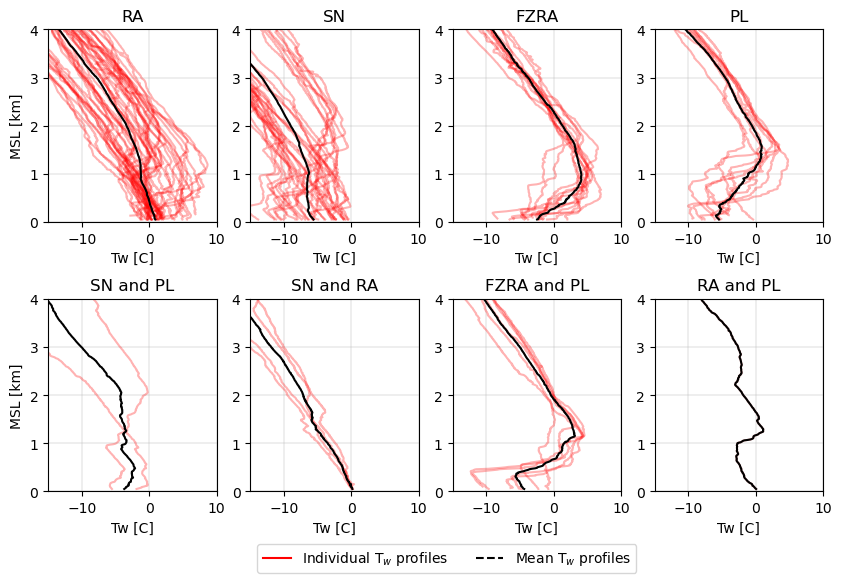

In [7]:
'''Read soundings to get surface temperature'''
heights_composite = np.arange(50,5000,10)
composite_sum = np.empty(8,dtype=object)
for i in range(8):
    composite_sum[i] = pd.DataFrame({'height':heights_composite,'Temp':np.zeros(len(heights_composite)),'Tw':np.zeros(len(heights_composite))})
    
n_curve_composite = np.zeros(8)

fig,axs = plt.subplots(2,4,figsize=(10,6))
ax = axs.ravel()
for index, row in df_manobs[df_manobs.Sounding==True].iterrows():
    # print(df_all_events.iloc[i].file.split('/')[-1])
    
    file = '/home/rml000/sitestore8/UQAM/projet_margaux/Pour_Mathieu_fig4/soundings_wintremix/'+ row.file.split('/')[-1]
    two_files_bool=False
    
    if "Sorel" in file:
        df = soundings_functions.read_soundings_data_Sorel(file)
        df['site'] = 'Sorel'
        # df['date'] = date_datetime
        df['file'] = file
            
    elif "Gault" in file:
        df = soundings_functions.read_soundings_data_Gault(file)
        df['site'] = 'Gault'
        # df['date'] = date_datetime
        df['file'] = file
    elif "Trois" in file : 
        df = soundings_functions.read_soundings_data_TR(file)
        df['site'] = 'Trois'
        # df['date'] = date_datetime
        df['file'] = file
    elif "Albany" in file:
        df = soundings_functions.read_soundings_data_Albany(file)
        df['site'] = 'Albany'
        # df['date'] = date_datetime
        df['file'] = file
    elif "CU" in file:
        df = soundings_functions.read_soundings_data_DOW(file)
        df['site'] = 'CU'
        df['file'] = file

   
    
    # output_sounding_analysis = new_warm_cold_layers_ERA5(df)
    # for output in output_sounding_analysis:
    #     df_all_events.at[index, output] = output_sounding_analysis[output]


# for index, row in df_all_events.iterrows():
    # if ((row.site=='Sorel') & ((str(row.dates)[:10]=='2022-02-22') or (str(row.dates)[:10]=='2022-02-23') ) ):
    # print('____________________________')
    # output_sounding_analysis = new_warm_cold_layers_ERA5(df)
    # for output in output_sounding_analysis:
    #     df_all_events.at[index, output] = output_sounding_analysis[output]

    types_to_plot = {'RA':0, 'SN':1, 'FZRA':2, 'PL':3,'SN and PL':4,'SN and RA':5,'FZRA and PL':6,'RA and PL':7}

    if  row['manobs_with_mix'] in types_to_plot:
        ax_index = types_to_plot[row['manobs_with_mix']]
        
        color='r'
        # ax[ax_index].plot(df.Temp,df.height,color=color)
        
        # ax[ax_index].grid('on')


        # #Interpolate
        df = df[2:]
        f_int_t = interp1d(df.height, df.Temp,bounds_error=False, fill_value=np.nan)
        f_int_tw = interp1d(df.height, df.Tw, bounds_error=False, fill_value=np.nan)
        df_inter = pd.DataFrame({'height':heights_composite,'Temp':f_int_t(heights_composite),'Tw':f_int_tw(heights_composite)})

        ax[ax_index].plot(df_inter.Tw,df_inter.height/1000.,color=color,alpha=0.3)
    
    
        if df_inter[df_inter.height<4000]['Tw'].isnull().any()==False:
            composite_sum[ax_index]['Tw']   = composite_sum[ax_index]['Tw'].values + df_inter['Tw'].values
            composite_sum[ax_index]['Temp'] = composite_sum[ax_index]['Temp'].values + df_inter['Temp'].values
            n_curve_composite[ax_index] = n_curve_composite[ax_index] + 1

for i in range(8):
    composite_sum[i]['Tw'] = composite_sum[i]['Tw']     / n_curve_composite[i]
    composite_sum[i]['Temp'] = composite_sum[i]['Temp'] / n_curve_composite[i]

    #     ax[i].plot(composite_sum[i].Temp,composite_sum[i].height/1000.,'k')
    ax[i].plot(composite_sum[i].Tw,composite_sum[i].height/1000.,'k')
    ax[i].set_xlim([-15,10])
    ax[i].set_ylim([0,4])
    
    ax[i].set_title(list(types_to_plot.keys())[i])

    ax[i].set_xlabel('Tw [C]')
    ax[i].grid('on',linewidth=0.3)
    
ax[0].set_ylabel('MSL [km]')
ax[4].set_ylabel('MSL [km]')
    

ax[5].plot(-100,-100,'r',label=r'Individual T$_w$ profiles')
ax[5].plot(-100,-100,'k--',label=r'Mean T$_w$ profiles')

ax[5].legend(loc='lower left',ncol=3, bbox_to_anchor=(0.,-0.46))

plt.subplots_adjust(hspace=0.4)

# plt.savefig('figures/tw-profiles.png',format='png',dpi=200,bbox_inches='tight')

plt.show()

# PL and FZRA

In [8]:
df_manobs_soundings = df_manobs[df_manobs.Sounding==True]

print('FZRA')
print(df_manobs_soundings[((df_manobs_soundings.manobs_with_mix=='FZRA'))][['site_date','CL_integral','WL_integral']])

print('PL')
print(df_manobs_soundings[((df_manobs_soundings.manobs_with_mix=='PL'))][['site_date','CL_integral','WL_integral']])

print('SN and PL')
print(df_manobs_soundings[((df_manobs_soundings.manobs_with_mix=='SN and PL'))][['site_date','CL_integral','WL_integral']])

print('SN and FZRA')
print(df_manobs_soundings[((df_manobs_soundings.manobs_with_mix=='SN and FZRA'))][['site_date','CL_integral','WL_integral']])

print('FZRA and PL')
print(df_manobs_soundings[((df_manobs_soundings.manobs_with_mix=='FZRA and PL'))][['site_date','CL_integral','WL_integral']])

print('RA and PL')
print(df_manobs_soundings[((df_manobs_soundings.manobs_with_mix=='RA and PL'))][['site_date','CL_integral','WL_integral']])

print('RA')
print(df_manobs_soundings[((df_manobs_soundings.manobs_with_mix=='RA'))][['site_date','CL_integral','WL_integral']])


FZRA
                      site_date  CL_integral  WL_integral
491   CU_DOW2022-02-22 22:10:00 -1809.361080  6742.626682
501   CU_DOW2022-02-23 00:10:00  -636.376861  6938.337433
825    Gault2022-02-22 22:30:00 -1005.854039  5886.396117
835    Gault2022-02-23 00:10:00  -313.082424  6086.652141
847    Gault2022-02-23 02:10:00  -116.010289  7133.930606
859    Gault2022-02-23 04:10:00    -6.915330  8928.316762
1406   Sorel2022-02-23 04:20:00 -1363.369193  4667.111760
1504   Sorel2022-03-06 10:10:00 -3993.926884   437.486892
1532   Sorel2022-03-06 14:50:00  -676.360095  5923.217005
1540   Sorel2022-03-06 16:10:00  -536.673399  8470.416380
1708   Trois2022-03-06 14:10:00 -2080.658872  1830.968949
1720   Trois2022-03-06 16:10:00  -809.047971  5185.590601
PL
                      site_date  CL_integral  WL_integral
97    Albany2022-02-18 07:10:00 -5762.319409  1315.640040
104   Albany2022-02-18 09:10:00 -9517.874225  1415.177052
474   CU_DOW2022-02-18 07:10:00 -6147.639925  1881.749254
789   

In [9]:
df_manobs_soundings = df_manobs[df_manobs.Sounding==True]

print('FZRA')
print(len(df_manobs_soundings[((df_manobs_soundings.manobs_with_mix=='FZRA'))][['site_date','CL_integral']]))

print('PL')
print(len(df_manobs_soundings[((df_manobs_soundings.manobs_with_mix=='PL'))][['site_date','CL_integral']]))

print('SN and PL')
print(len(df_manobs_soundings[((df_manobs_soundings.manobs_with_mix=='SN and PL'))][['site_date','CL_integral']]))

print('FZRA and PL')
print(len(df_manobs_soundings[((df_manobs_soundings.manobs_with_mix=='FZRA and PL'))][['site_date','CL_integral']]))

print('SN and FZRA')
print(len(df_manobs_soundings[((df_manobs_soundings.manobs_with_mix=='SN and FZRA'))][['site_date','CL_integral']]))


print('RA and PL')
print(len(df_manobs_soundings[((df_manobs_soundings.manobs_with_mix=='RA and PL'))][['site_date','CL_integral']]))



FZRA
12
PL
9
SN and PL
2
FZRA and PL
6
SN and FZRA
1
RA and PL
1
